In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
# Load the document assuming it's a CSV file
  # Adjust the file extension if necessary
data = pd.read_csv('TOTF_book_03_04_2017.csv')

In [ ]:
# Filter the data for the specific date

L_bid = ['bidQ_1', 'bidQ_2', 'bidQ_3', 'bidQ_4', 'bidQ_5']
L_ask = ['askQ_1','askQ_2', 'askQ_3',  'askQ_4', 'askQ_5']
nlags = 360

unique_dates = data['date'].unique()
temps = []
heure = ['09:', '10:', '11:', '12:', '13:', '14:', '15:', '16:']
for i in heure:
    for n in range(0,10):
        temps.append(i+'0'+f"{n}")
    for n in range(10,60):
        temps.append(i+f"{n}")

augmented_volume_acf = np.zeros((len(unique_dates) ,1 + nlags))
reduced_volume_acf = np.zeros((len(unique_dates) , 1 + nlags))
normal_volume_acf = np.zeros((len(unique_dates) ,1 + nlags))

for d in range(len(unique_dates)): 
    dates = unique_dates[d]
    data_day = data[data['date'] == dates]
    argumented_volumeT = np.zeros(len(temps))
    reduced_volumeT = np.zeros(len(temps))
    normal_volumeT = np.zeros(len(temps))
    for h in range(len(temps)):
        i = temps[h]
        data_HF = data_day[data_day['time'].str.startswith(i)] 
        bidQ = L_bid[0]
        data_HF = np.diff(data_HF[bidQ].values)
        negative_values = np.sum(data_HF[data_HF < 0])
        positive_values = np.sum(data_HF[data_HF > 0])
        normal_volumeT[h] = np.sum(data_HF)
        argumented_volumeT[h] = positive_values
        reduced_volumeT[h] = negative_values
    augmented_volume_acf[d,:] = sm.tsa.stattools.acf(argumented_volumeT, nlags=nlags, fft=True)
    reduced_volume_acf[d,:] = sm.tsa.stattools.acf(reduced_volumeT, nlags = nlags, fft=True)
    normal_volume_acf[d,:] = sm.tsa.stattools.acf(normal_volumeT, nlags=nlags, fft=True)

361 361 361


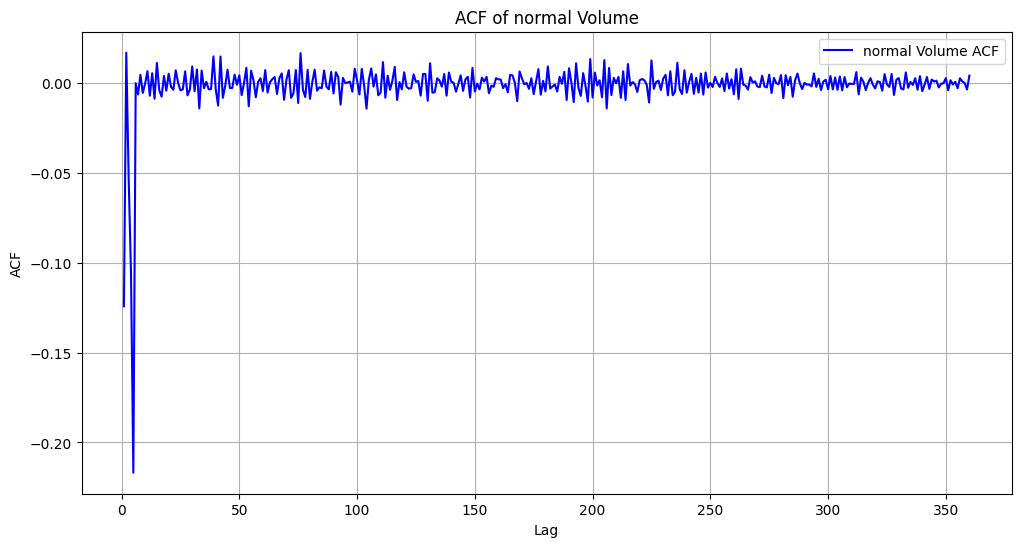

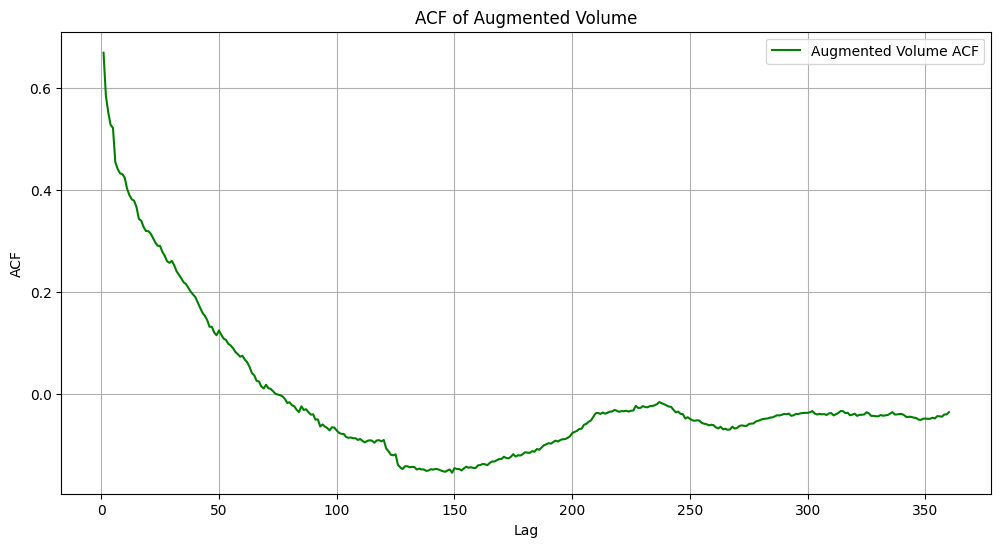

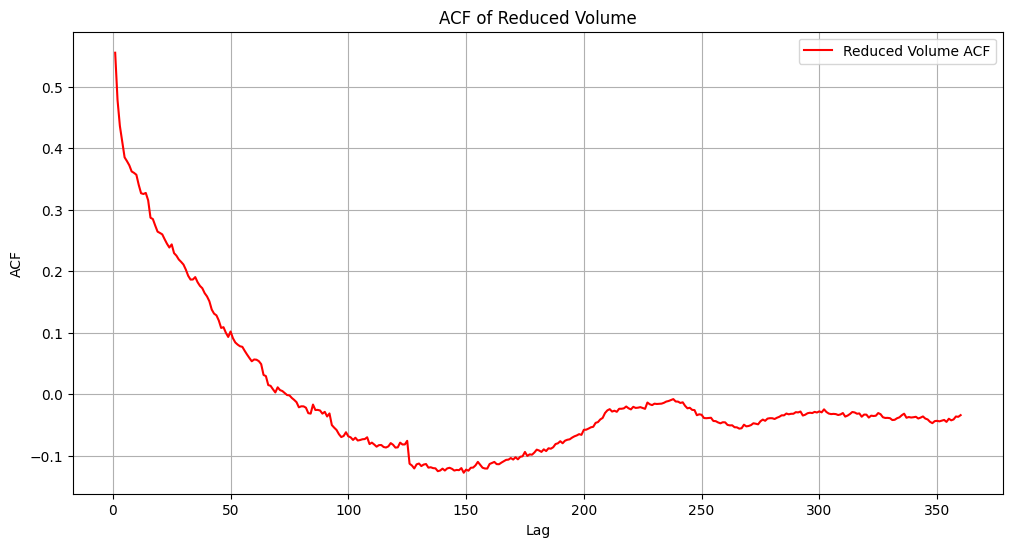

In [ ]:
normal_volume = np.mean(normal_volume_acf, axis=0)
augmented_volume = np.mean(augmented_volume_acf, axis=0)
reduced_volume = np.mean(reduced_volume_acf, axis=0)

print(len(augmented_volume), len(reduced_volume), len(normal_volume))

# Plot the ACF of normal_volume excluding x=0
plt.figure(figsize=(12, 6))
plt.plot(range(1,nlags+1),normal_volume[1:], label='normal Volume ACF', color='blue')
plt.xlabel('Lag')

plt.ylabel('ACF')

plt.title('ACF of normal Volume')
plt.legend()
plt.grid()
plt.show()

# Plot the ACF of augmented_volume excluding x=0
plt.figure(figsize=(12, 6))
plt.plot(range(1,nlags+1), augmented_volume[1:], label='Augmented Volume ACF', color='green')

plt.xlabel('Lag')
plt.ylabel('ACF')
plt.title('ACF of Augmented Volume')
plt.legend()
plt.grid()
plt.show()

# Plot the ACF of reduced_volume excluding x=0
plt.figure(figsize=(12, 6))
plt.plot(range(1,nlags+1),reduced_volume[1:], label='Reduced Volume ACF', color='red')
plt.xlabel('Lag')

plt.ylabel('ACF')
plt.title('ACF of Reduced Volume')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Filter the data for the specific date

L_bid = ['bidQ_1', 'bidQ_2', 'bidQ_3', 'bidQ_4', 'bidQ_5']
L_ask = ['askQ_1','askQ_2', 'askQ_3',  'askQ_4', 'askQ_5']
nlags = 360

unique_dates = data['date'].unique()
temps = []
heure = ['09:', '10:', '11:', '12:', '13:', '14:', '15:', '16:']
for i in heure:
    for n in range(0,10):
        temps.append(i+'0'+f"{n}")
    for n in range(10,60):
        temps.append(i+f"{n}")
augmented_volume_acf2 = np.zeros((len(unique_dates) ,1 + nlags))
reduced_volume_acf2 = np.zeros((len(unique_dates) , 1 + nlags))
normal_volume_acf2 = np.zeros((len(unique_dates) ,1 + nlags))

for d in range(len(unique_dates)): 
    dates = unique_dates[d]
    data_day = data[data['date'] == dates]
    argumented_volumeT2 = np.zeros(len(temps))
    reduced_volumeT2 = np.zeros(len(temps))
    normal_volumeT2 = np.zeros(len(temps))
    for h in range(len(temps)):
        i = temps[h]
        data_HF = data_day[data_day['time'].str.startswith(i)] 
        bidQ = L_ask[0]
        data_HF = np.diff(data_HF[bidQ].values)
        negative_values = np.sum(data_HF[data_HF < 0])
        positive_values = np.sum(data_HF[data_HF > 0])
        normal_volumeT2[h] = np.sum(data_HF)
        argumented_volumeT2[h] = positive_values
        reduced_volumeT2[h] = negative_values
    augmented_volume_acf2[d,:] = sm.tsa.stattools.acf(argumented_volumeT2, nlags=nlags, fft=True)
    reduced_volume_acf2[d,:] = sm.tsa.stattools.acf(reduced_volumeT2, nlags = nlags, fft=True)
    normal_volume_acf2[d,:] = sm.tsa.stattools.acf(normal_volumeT2, nlags=nlags, fft=True)

361 361 361


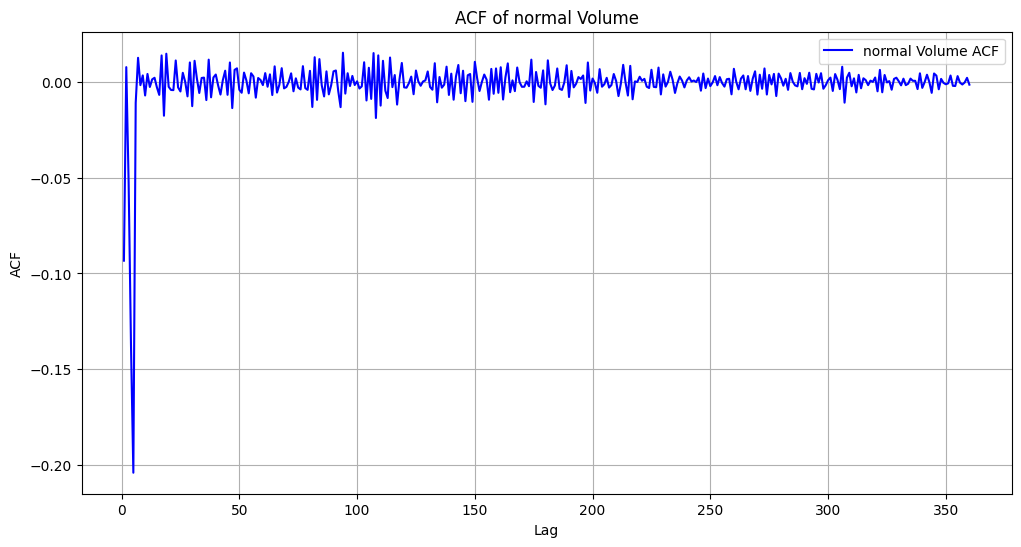

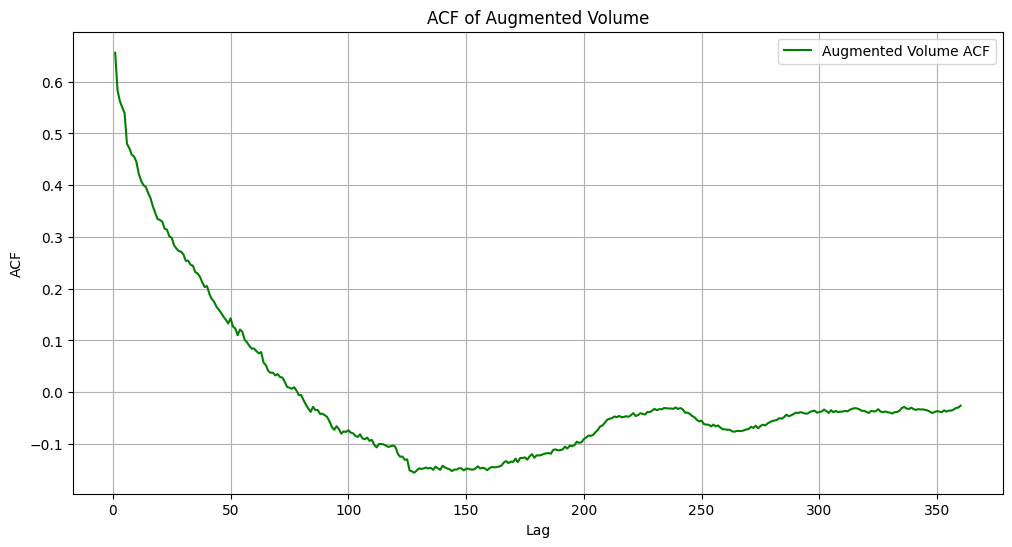

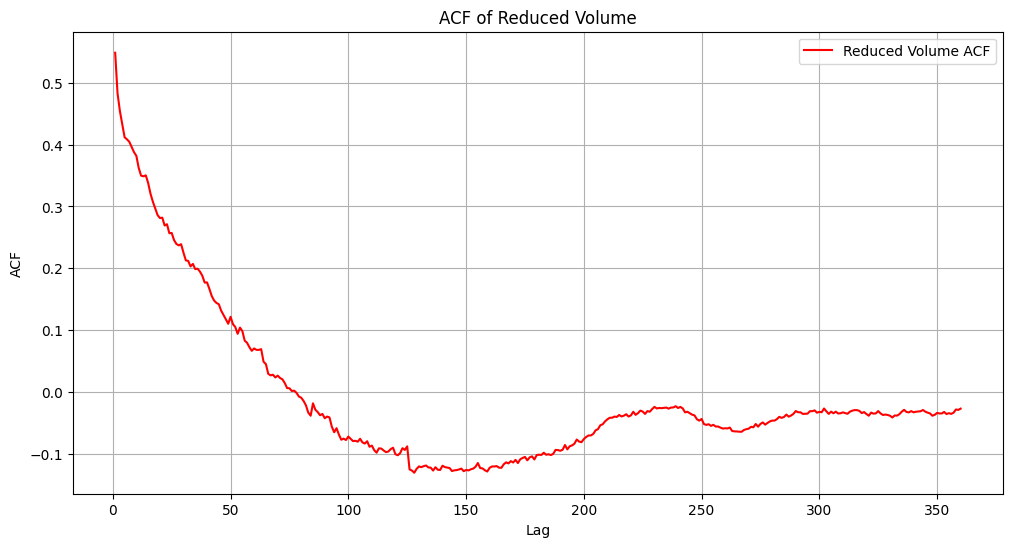

In [ ]:
normal_volume2 = np.mean(normal_volume_acf2, axis=0)
augmented_volume2 = np.mean(augmented_volume_acf2, axis=0)
reduced_volume2 = np.mean(reduced_volume_acf2, axis=0)

#cor_volume_augmented = sm.tsa.acf(augmented_volume, nlags=nlags, fft=True)
#cor_volume_reduced = sm.tsa.acf(reduced_volume, nlags=nlags, fft=True)
#cor_volume_normal = sm.tsa.acf(normal_volume, nlags=nlags, fft=True)

print(len(augmented_volume2), len(reduced_volume2), len(normal_volume2))

# Plot the ACF of normal_volume excluding x=0
plt.figure(figsize=(12, 6))
plt.plot(range(1,nlags+1),normal_volume2[1:], label='normal Volume ACF', color='blue')
plt.xlabel('Lag')

plt.ylabel('ACF')

plt.title('ACF of normal Volume')
plt.legend()
plt.grid()
plt.show()

# Plot the ACF of augmented_volume excluding x=0
plt.figure(figsize=(12, 6))
plt.plot(range(1,nlags+1), augmented_volume2[1:], label='Augmented Volume ACF', color='green')

plt.xlabel('Lag')
plt.ylabel('ACF')
plt.title('ACF of Augmented Volume')
plt.legend()
plt.grid()
plt.show()

# Plot the ACF of reduced_volume excluding x=0
plt.figure(figsize=(12, 6))
plt.plot(range(1,nlags+1),reduced_volume2[1:], label='Reduced Volume ACF', color='red')
plt.xlabel('Lag')

plt.ylabel('ACF')
plt.title('ACF of Reduced Volume')
plt.legend()
plt.grid()
plt.show()

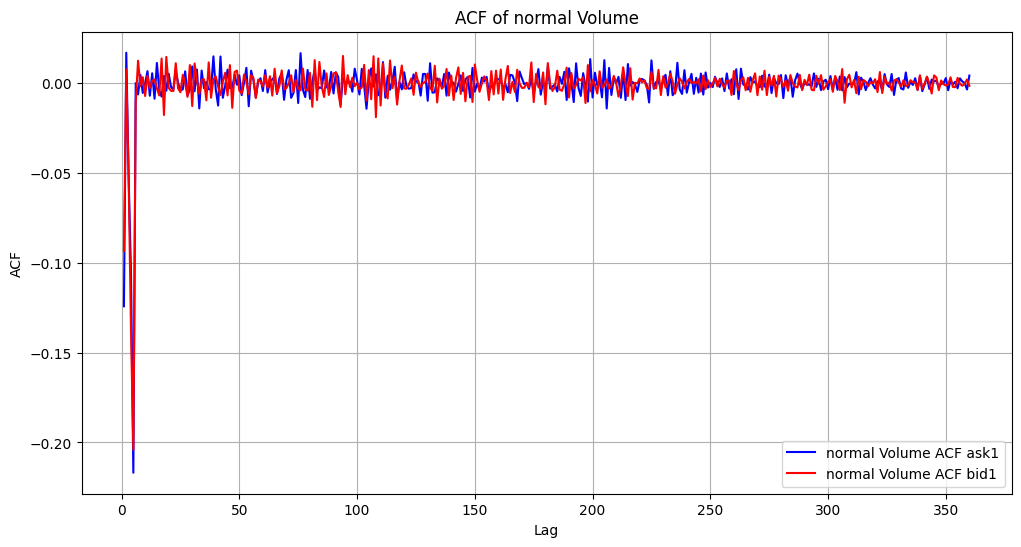

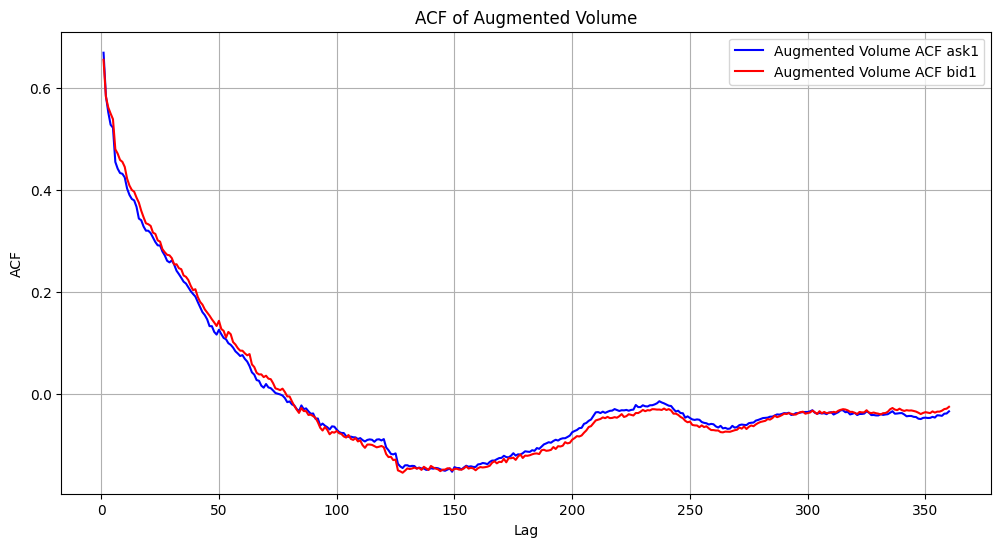

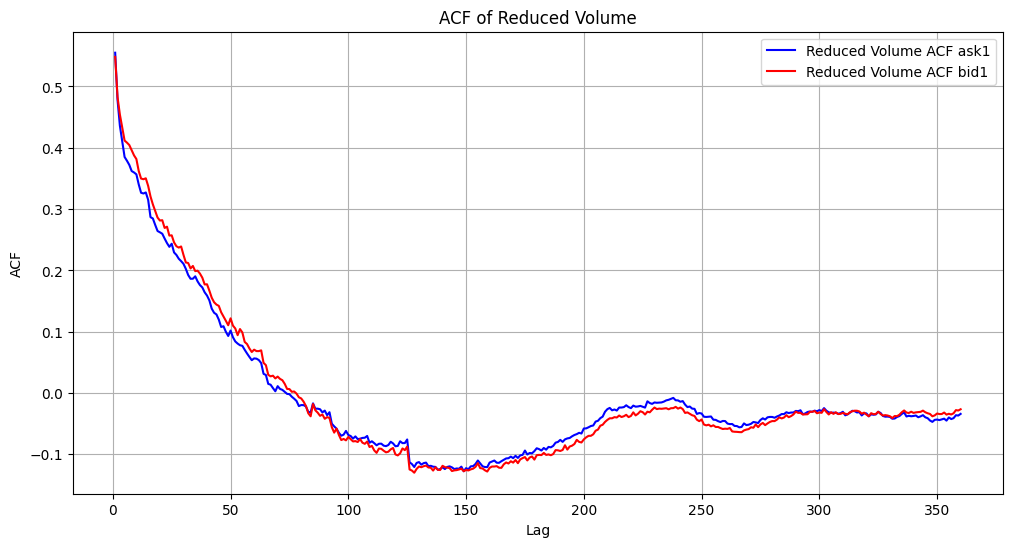

In [ ]:
# Plot the ACF of normal_volume excluding x=0
plt.figure(figsize=(12, 6))
plt.plot(range(1,nlags+1),normal_volume[1:], label='normal Volume ACF ask1', color='blue')
plt.plot(range(1,nlags+1),normal_volume2[1:], label='normal Volume ACF bid1', color='red')
plt.xlabel('Lag')

plt.ylabel('ACF')

plt.title('ACF of normal Volume')
plt.legend()
plt.grid()
plt.show()

# Plot the ACF of augmented_volume excluding x=0
plt.figure(figsize=(12, 6))
plt.plot(range(1,nlags+1), augmented_volume[1:], label='Augmented Volume ACF ask1', color='blue')
plt.plot(range(1,nlags+1), augmented_volume2[1:], label='Augmented Volume ACF bid1', color='red')
plt.xlabel('Lag')
plt.ylabel('ACF')
plt.title('ACF of Augmented Volume')
plt.legend()
plt.grid()
plt.show()

# Plot the ACF of reduced_volume excluding x=0
plt.figure(figsize=(12, 6))
plt.plot(range(1,nlags+1),reduced_volume[1:], label='Reduced Volume ACF ask1', color='blue')
plt.plot(range(1,nlags+1),reduced_volume2[1:], label='Reduced Volume ACF bid1', color='red')
plt.xlabel('Lag')

plt.ylabel('ACF')
plt.title('ACF of Reduced Volume')
plt.legend()
plt.grid()
plt.show()